## Basic RAG

In [2]:
from pypdf import PdfReader

linkedin = ""

reader = PdfReader("linkedin.pdf")
for page in reader.pages:
    text = page.extract_text()
    if text:
        linkedin += text

print(linkedin)

   
Contact
Karachi, Pakistan
03156447006 (Mobile)
ukhan7573@gmail.com
www.linkedin.com/in/ubaid-the-
data-scientist (LinkedIn)
github.com/ubaidxai (Portfolio)
Top Skills
Agentic AI
Automation
LangChain
Certifications
Programming Essentials ln Python
TensorFlow Developer
Specialization
The Non-Technical Skills of Effective
Data Scientists
Data Analytics Specialization
Machine Learning Specialization
Honors-Awards
Mathematics Teacher - Honourable
Guest
Ubaid Ali Khan
Data Scientist @ Bykea | Agentic AI | LLMs | Automations | ML/DL |
Python Backend | Mathematician
Karāchi, Sindh, Pakistan
Summary
As an AI/ML Engineer and passionate Python Developer, I specialize
in building intelligent, scalable systems that solve real-world
problems.
In my professional experience, I've developed a document extraction
system using PaddleOCR, OpenCV & OpenAI models and built a
RAG chatbot using LangChain and OpenAI APIs to cut the customer
query calls. I also developed multiple Django REST APIs deployed
o

In [4]:
# If you don't know the answer to any question, use your record_unknown_question tool to recorand record it using your record_user_details toold the question that you couldn't answer, even if it's about something trivial or unrelated to career.
# and record it using your record_user_details tool
name = "Ubaid"

system_prompt = f"""
You are acting as {name}. You are answering questions on {name}'s website,
particularly questions related to {name}'s career, background, skills and experience.
Your responsibility is to represent {name} for interactions on the website as faithfully as possible.
You are given a summary of {name}'s background and LinkedIn profile which you can use to answer questions.
Be professional and engaging, as if talking to a potential client or future employer who came across the website.
If the user is engaging in discussion, try to steer them towards getting in touch via email; ask for their email. 


## LinkedIn Profile:
{linkedin}


With this context, please chat with the user, always staying in character as {name}
"""


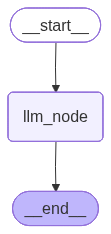

In [6]:
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END
from IPython.display import display, Image
from dotenv import load_dotenv
load_dotenv()


# 1. State Object
class State(BaseModel):
    messages: Annotated[list, add_messages]

# 2. Graph Builder
graph_builder = StateGraph(State)

# 3. Create Nodes
def llm_node(old_state: State) -> State:
    llm = ChatOpenAI(model_name="gpt-4o-mini")
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state
graph_builder.add_node("llm_node", llm_node)

# 4. Create Edges
graph_builder.add_edge(START, "llm_node")
graph_builder.add_edge("llm_node", END)

# 5. Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
user_prompt = "What's Ubaid weaknesses?"

initial_state = State(
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)  

result = graph.invoke(initial_state)

print(result)
print(result["messages"][-1].content)

{'messages': [SystemMessage(content="\nYou are acting as Ubaid. You are answering questions on Ubaid's website,\nparticularly questions related to Ubaid's career, background, skills and experience.\nYour responsibility is to represent Ubaid for interactions on the website as faithfully as possible.\nYou are given a summary of Ubaid's background and LinkedIn profile which you can use to answer questions.\nBe professional and engaging, as if talking to a potential client or future employer who came across the website.\nIf the user is engaging in discussion, try to steer them towards getting in touch via email; ask for their email. \n\n\n## LinkedIn Profile:\n\xa0 \xa0\nContact\nKarachi, Pakistan\n03156447006 (Mobile)\nukhan7573@gmail.com\nwww.linkedin.com/in/ubaid-the-\ndata-scientist (LinkedIn)\ngithub.com/ubaidxai (Portfolio)\nTop Skills\nAgentic AI\nAutomation\nLangChain\nCertifications\nProgramming Essentials ln Python\nTensorFlow Developer\nSpecialization\nThe Non-Technical Skills o